Epoch 1/5, Loss: 0.2317
Epoch 2/5, Loss: 0.0970
Epoch 3/5, Loss: 0.0659
Epoch 4/5, Loss: 0.0513
Epoch 5/5, Loss: 0.0403
Test Accuracy: 97.67%


C:\Users\123\AppData\Local\Temp\ipykernel_13156\4053951799.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


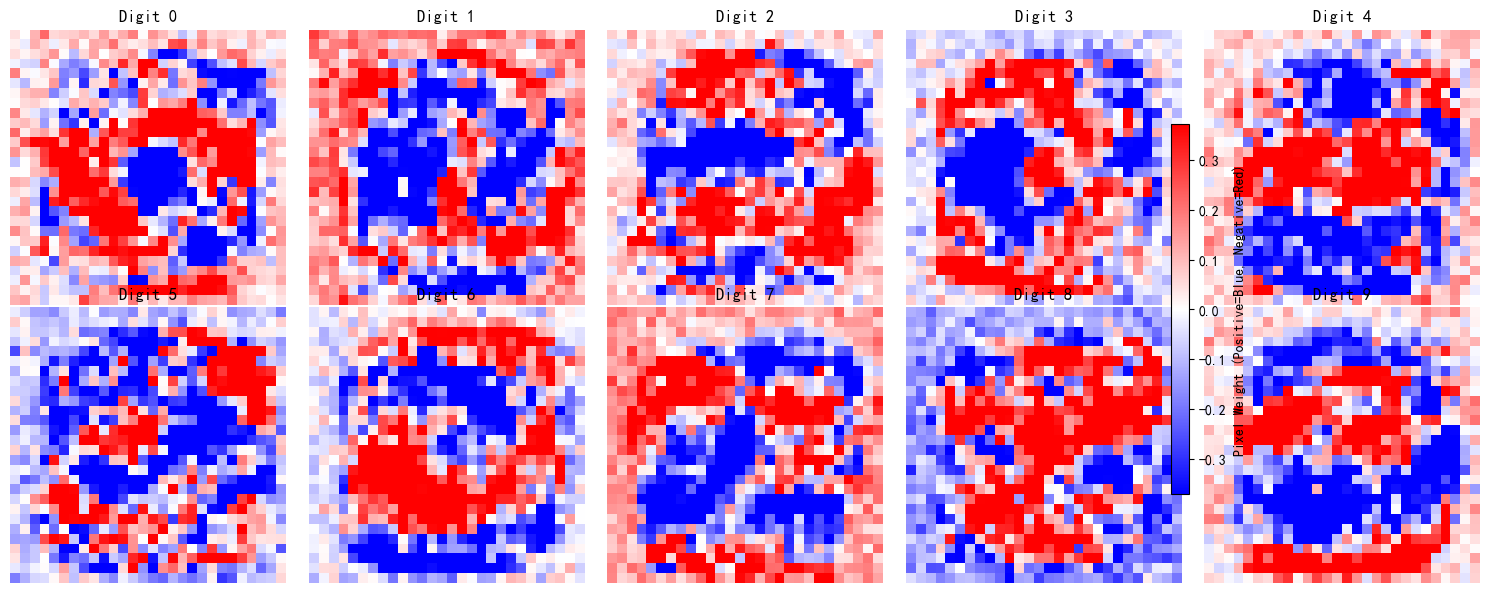

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root='./mnist_data', 
    train=True,       
    download=True,      
    transform=transform
)
test_dataset = datasets.MNIST(
    root='./mnist_data',
    train=False,         
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256) 
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)     
        self.relu = nn.ReLU()      
        self.flatten=nn.Flatten()      

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)        
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5  
model.train()  
for epoch in range(epochs):
    total_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        output = model(data)
        loss = criterion(output, target)
        
        optimizer.zero_grad()  
        loss.backward()        
        optimizer.step()       
        
        total_loss += loss.item()
    
    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}')

model.eval() 
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

print(f'Test Accuracy: {100 * correct / total:.2f}%')


combined_weights = model.fc3.weight @ model.fc2.weight @ model.fc1.weight
combined_weights = combined_weights.cpu().detach().numpy()  

fig, axes = plt.subplots(2, 5, figsize=(15, 6))  
axes = axes.flatten()

for digit in range(10):
    weight_map = combined_weights[digit].reshape(28, 28)
    
    im = axes[digit].imshow(weight_map, cmap='bwr', vmin=-weight_map.std(), vmax=weight_map.std())
    axes[digit].set_title(f'Digit {digit}', fontsize=12)
    axes[digit].axis('off')  

cbar = fig.colorbar(im, ax=axes, shrink=0.8)
cbar.set_label('Pixel Weight (Positive=Blue, Negative=Red)', fontsize=10)

plt.tight_layout()
plt.show()